# Series de tiempo

In [303]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [304]:
url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv'
df = pd.read_csv(url,index_col=0)
df['time'] = pd.to_datetime(df['time'])

In [305]:
columns = df.columns
columns = list(columns)
for i in range(len(columns)):
    columns[i] = columns[i].replace(columns[i],re.sub(r'([a-z])([A-Z])',r'\1_\2',columns[i]))

df.columns = columns
df.columns= (
    df.columns
    .str.replace('_',' ')
    .str.title()
)

In [306]:
df = df.set_index('Time')
print(np.mean(df['Tick Volume']))
print(len(df['Tick Volume']))
df

3690.2494
5000


,Open,High,Low,Close,Tick Volume,Spread,Real Volume,Mean Close Open,Diff Close,Diff Open,Diff Mean Close Open
Time,,,,,,,,,,,
2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365
...,...,...,...,...,...,...,...,...,...,...,...
2023-05-12 19:00:00,1.08552,1.08569,1.08485,1.08514,2275,8,0,1.085330,-0.00038,-0.00071,-0.000545
2023-05-12 20:00:00,1.08516,1.08567,1.08502,1.08546,1676,8,0,1.085310,0.00032,-0.00036,-0.000020
2023-05-12 21:00:00,1.08546,1.08546,1.08487,1.08531,1828,8,0,1.085385,-0.00015,0.00030,0.000075


Los datos contienen información sobre los precios de apertura, cierre, máximos y mínimos de cada hora, desde el 25 de julio de 2022 hasta el 12 de mayo de 2023. Además, incluyen la cantidad de registros tomados por hora, con un promedio de 3690, para un total de 5000 horas registradas.

In [307]:
df.isnull().values.any()

np.False_

In [308]:
df = df[['Close']]

In [309]:
df['DiffPrice'] = df['Close'].diff().fillna(0)

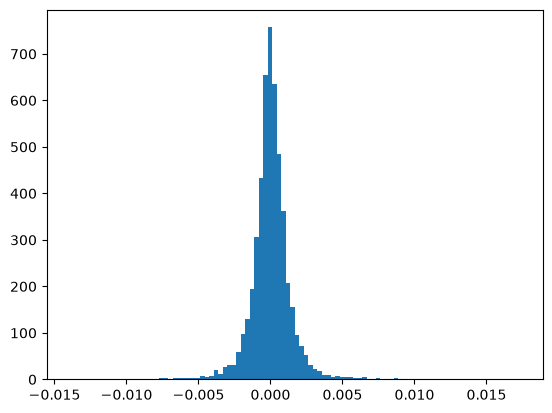

In [310]:
a,b,c =plt.hist(df['DiffPrice'], bins=100)
plt.show()

2026-09-03 15:01:52.523 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=106890.256569, AIC=-51517.02, KS=0.0906
2026-09-03 15:01:52.751 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=106844.955940, AIC=-51514.68, KS=0.0910
2026-09-03 15:01:52.787 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted burr: error=722062.088559, AIC=-37772.84, KS=0.3864
2026-09-03 15:01:53.957 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=106649.028247, AIC=-51521.07, KS=0.0916
2026-09-03 15:01:53.992 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=923640.979614, AIC=-17726.79, KS=0.5913


(np.float64(9907.00160450517),
 np.float64(19171.51466653293),
 np.float64(-0.17163080804426212),
 np.float64(0.5037963601619961))

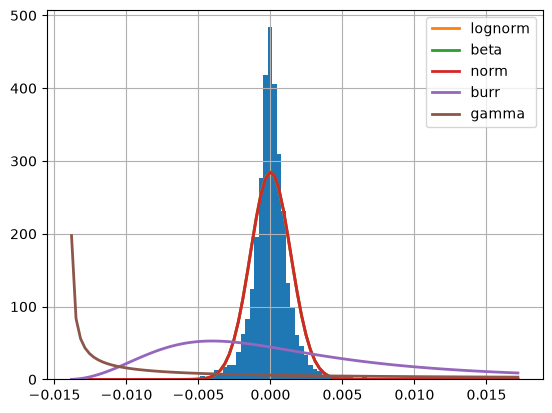

In [311]:
from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(df['DiffPrice'],
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]



2026-09-03 15:01:54.420 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=106649.028247, AIC=-51521.07, KS=0.0916


{'lognorm': {'s': np.float64(0.009513239054248463),
  'loc': np.float64(-0.14710494310881345),
  'scale': np.float64(0.14711058971713395)}}

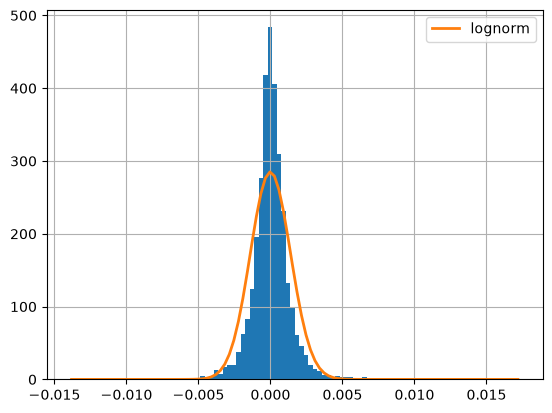

In [312]:
f = Fitter(df['DiffPrice'],
           distributions=[
                          'lognorm'])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta


In [313]:
print(f'La distribucion que mejor se ajusta es: lognorm')

La distribucion que mejor se ajusta es: lognorm


Los parámetros de la distribución lognormal que mejor se ajusta a mis datos son: mu=3.0387299908797143e-05, sigma=0.0009196781146788482, amplitude=0.000945036282742772


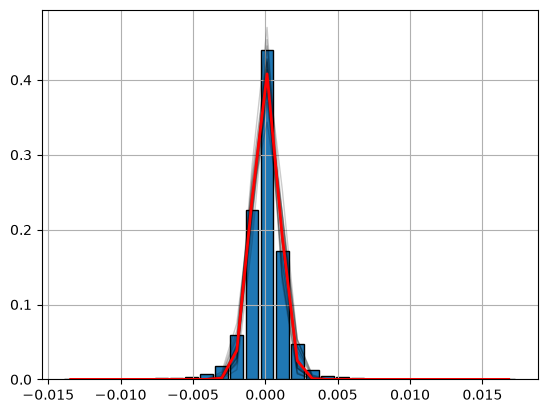

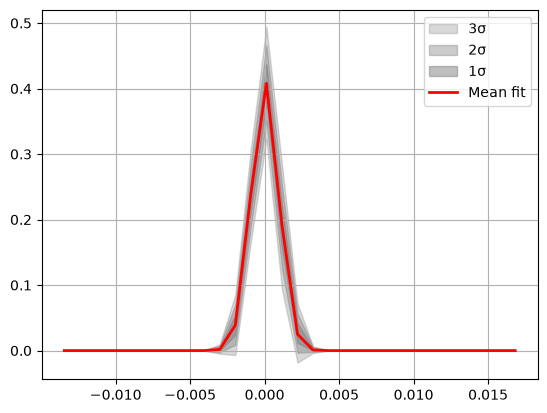

In [314]:
from fitter import HistFit
from pylab import hist
import scipy.stats
data = df['DiffPrice']
Y, X, _ = hist(data, bins=30)
hf = HistFit(X=X, Y=Y)
hf.fit(error_rate=0.03, Nfit=20)
print(f'Los parámetros de la distribución lognormal que mejor se ajusta a mis datos son: mu={hf.mu}, sigma={hf.sigma}, amplitude={hf.amplitude}')

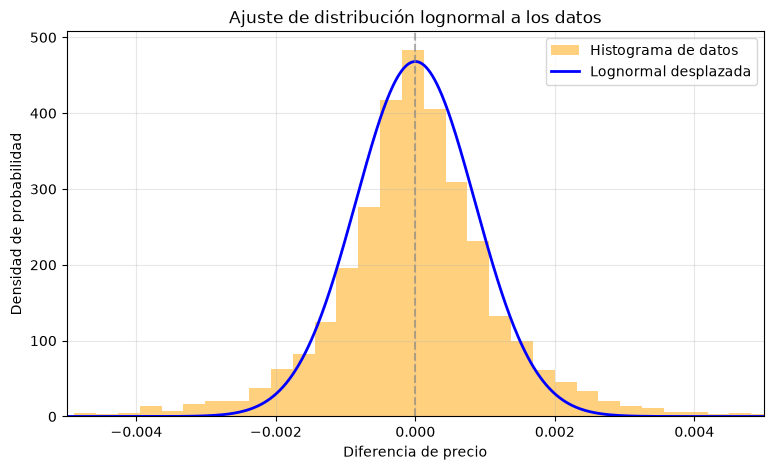

In [315]:
from scipy.stats import lognorm

mu = 3.102822991168162e-05
sigma = 0.0008521188396537295

# Ubicar el máximo de la curva en cero
scale = np.exp(mu)
loc = -np.exp(mu - sigma**2)

X = np.linspace(-0.015, 0.015, 2000)
Y = lognorm.pdf(X, s=sigma, loc=loc, scale=scale)

plt.figure(figsize=(9, 5))

plt.hist(
    df["DiffPrice"].dropna(),
    bins=100,
    density=True,
    alpha=0.5,
    color="orange",
    label="Histograma de datos"
)

plt.plot(
    X, Y,
    color="blue",
    linewidth=2,
    label="Lognormal desplazada"
)

plt.axvline(0, color="gray", linestyle="--", alpha=0.6)
plt.xlim(-0.005, 0.005)
plt.xlabel("Diferencia de precio")
plt.ylabel("Densidad de probabilidad")
plt.grid(alpha=0.3)
plt.title("Ajuste de distribución lognormal a los datos")
plt.legend()
plt.show()

In [316]:
df_2023=df[df.index.year == 2023]
print('Promedios cada 15 dias')
df_2023.groupby(pd.Grouper( freq='15D')).mean()

Promedios cada 15 dias


,Close,DiffPrice
Time,,
2023-01-02,1.069361,0.000047
2023-01-17,1.085565,0.000015
2023-02-01,1.077679,-0.000066
2023-02-16,1.063150,-0.000034
2023-03-03,1.063186,0.000026
2023-03-18,1.080936,0.000074
2023-04-02,1.093090,0.000063
2023-04-17,1.099084,-0.000006
2023-05-02,1.098889,-0.000059


In [317]:
print('Promedios cada semana')
df_2023.groupby(pd.Grouper( freq='W')).mean()

Promedios cada semana


,Close,DiffPrice
Time,,
2023-01-08,1.059972,-0.000047
2023-01-15,1.076002,0.000156
2023-01-22,1.082041,0.000020
2023-01-29,1.088414,0.000010
2023-02-05,1.089281,-0.000062
2023-02-12,1.073363,-0.000097
2023-02-19,1.069648,0.000014
2023-02-26,1.063374,-0.000124
2023-03-05,1.060854,0.000073


In [318]:
print('Promedios cada mes')
df_2023.groupby(pd.Grouper( freq='MS')).mean()

Promedios cada mes


,Close,DiffPrice
Time,,
2023-01-01,1.077463,0.000031
2023-02-01,1.071167,-0.000060
2023-03-01,1.070874,0.000049
2023-04-01,1.096051,0.000036
2023-05-01,1.098980,-0.000069


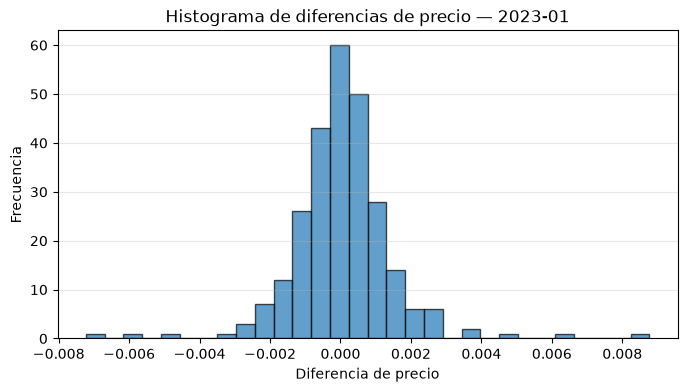

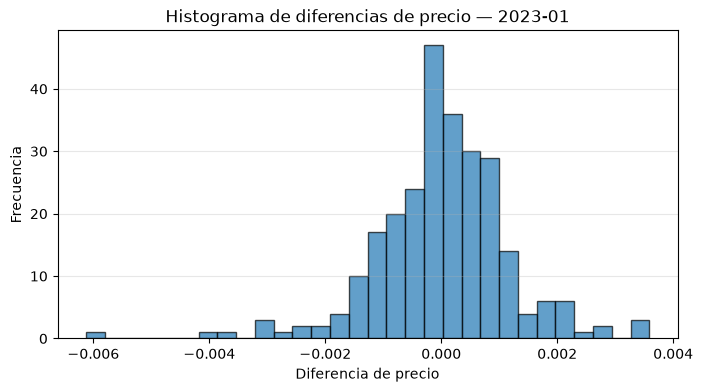

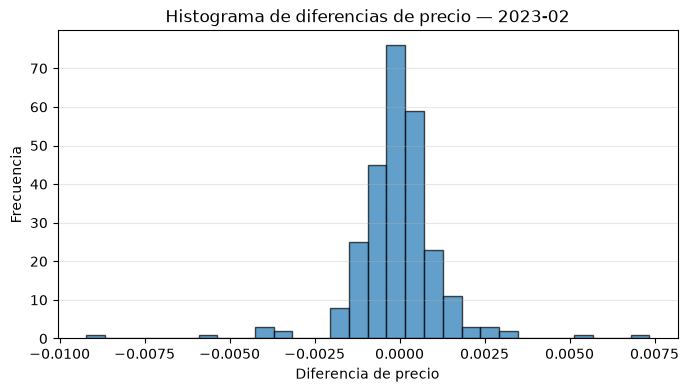

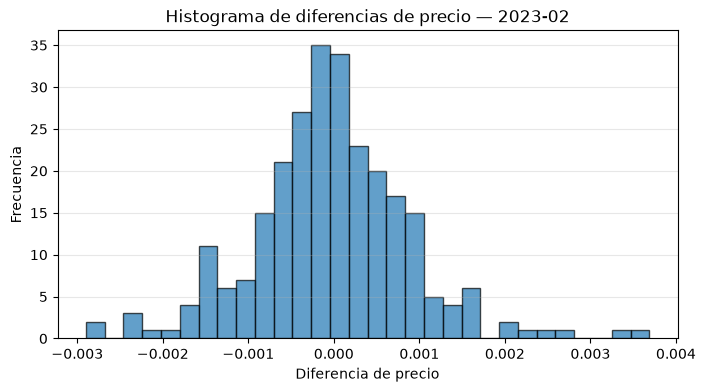

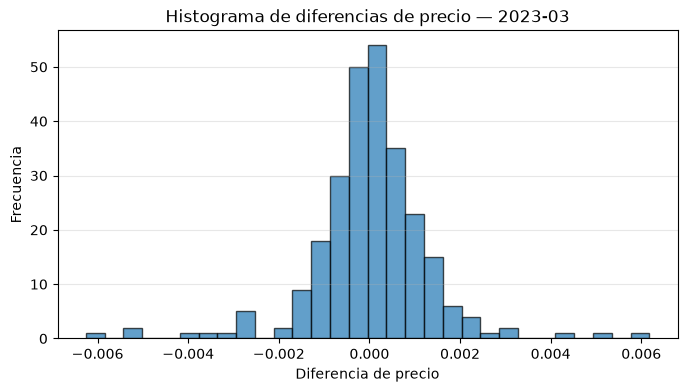

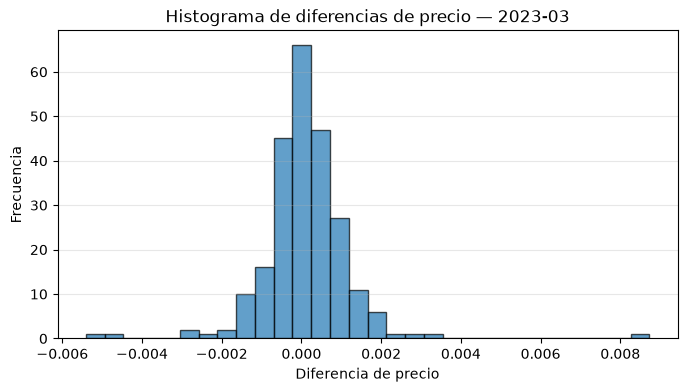

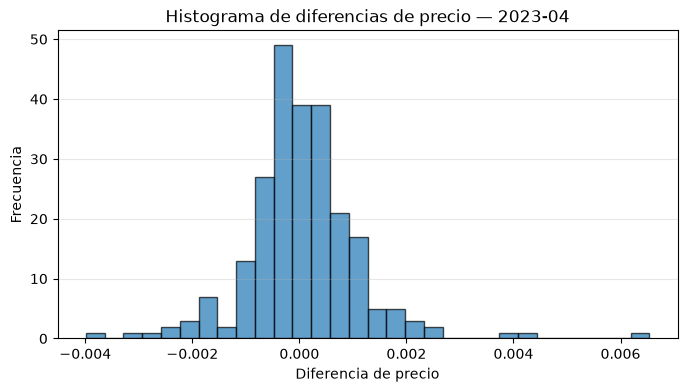

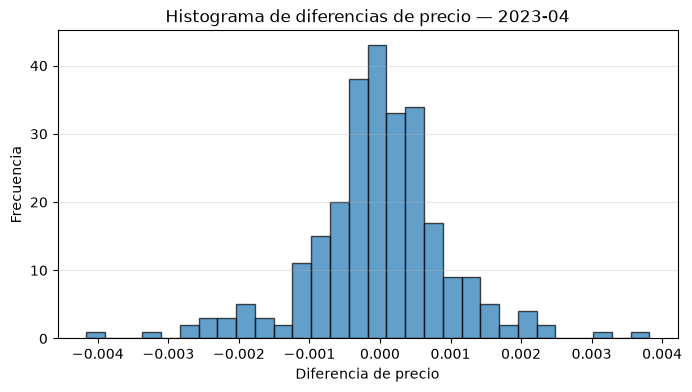

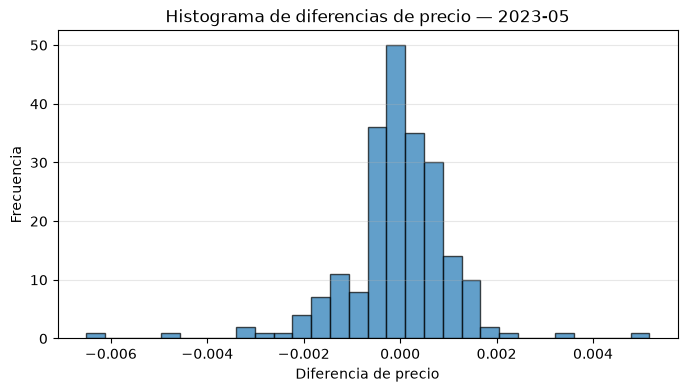

In [319]:
q=df_2023.groupby(pd.Grouper( freq='15D'))
for name, group in q:
    Datos = group["DiffPrice"].dropna()

    if Datos.empty:
        continue

    plt.figure(figsize=(8, 4))
    plt.hist(Datos, bins=30, alpha=0.7, edgecolor="black")

    plt.title(f"Histograma de diferencias de precio — {name:%Y-%m}")
    plt.xlabel("Diferencia de precio")
    plt.ylabel("Frecuencia")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# Analisis de datos con pandas 

In [320]:
import pandas as pd

df = pd.read_csv("wdbc.data", header=None)
Columnas = [
    "ID", "Diagnosis",
    "RadiusMean", "TextureMean", "PerimeterMean", "AreaMean",
    "SmoothnessMean", "CompactnessMean", "ConcavityMean",
    "ConcavePointsMean", "SymmetryMean", "FractalDimensionMean",

    "RadiusSE", "TextureSE", "PerimeterSE", "AreaSE",
    "SmoothnessSE", "CompactnessSE", "ConcavitySE",
    "ConcavePointsSE", "SymmetrySE", "FractalDimensionSE",

    "RadiusWorst", "TextureWorst", "PerimeterWorst", "AreaWorst",
    "SmoothnessWorst", "CompactnessWorst", "ConcavityWorst",
    "ConcavePointsWorst", "SymmetryWorst", "FractalDimensionWorst"
]

df.columns = Columnas

display(df.head())

,ID,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [321]:
df.head()
df.tail()
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     569 non-null    int64  
 1   Diagnosis              569 non-null    str    
 2   RadiusMean             569 non-null    float64
 3   TextureMean            569 non-null    float64
 4   PerimeterMean          569 non-null    float64
 5   AreaMean               569 non-null    float64
 6   SmoothnessMean         569 non-null    float64
 7   CompactnessMean        569 non-null    float64
 8   ConcavityMean          569 non-null    float64
 9   ConcavePointsMean      569 non-null    float64
 10  SymmetryMean           569 non-null    float64
 11  FractalDimensionMean   569 non-null    float64
 12  RadiusSE               569 non-null    float64
 13  TextureSE              569 non-null    float64
 14  PerimeterSE            569 non-null    float64
 15  AreaSE           

El conjunto de datos `df` contiene información de 569 pacientes con tumores de mama, organizada en 32 columnas: un identificador, un diagnóstico y 30 características numéricas. No presenta datos faltantes y ocupa aproximadamente 142.4 KB en memoria.

In [322]:
NulosPorColumna = df.isna().sum()

display(NulosPorColumna)
print("Total de valores nulos:", NulosPorColumna.sum())

ID                       0
Diagnosis                0
RadiusMean               0
TextureMean              0
PerimeterMean            0
AreaMean                 0
SmoothnessMean           0
CompactnessMean          0
ConcavityMean            0
ConcavePointsMean        0
SymmetryMean             0
FractalDimensionMean     0
RadiusSE                 0
TextureSE                0
PerimeterSE              0
AreaSE                   0
SmoothnessSE             0
CompactnessSE            0
ConcavitySE              0
ConcavePointsSE          0
SymmetrySE               0
FractalDimensionSE       0
RadiusWorst              0
TextureWorst             0
PerimeterWorst           0
AreaWorst                0
SmoothnessWorst          0
CompactnessWorst         0
ConcavityWorst           0
ConcavePointsWorst       0
SymmetryWorst            0
FractalDimensionWorst    0
dtype: int64

Total de valores nulos: 0


Si faltara algún dato numérico, lo reemplazaría por la mediana, dado que es menos sensible a los valores extremos y se calcula a partir de los datos disponibles. Sin embargo, si faltara el diagnóstico, que es una variable categórica, no lo reemplazaría, ya que no sería adecuado asignar un diagnóstico sin conocerlo.

In [323]:
df["Diagnosis"].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

`Diagnosis` es una variable categórica que indica si el tumor de cada paciente es benigno (`B`) o maligno (`M`).

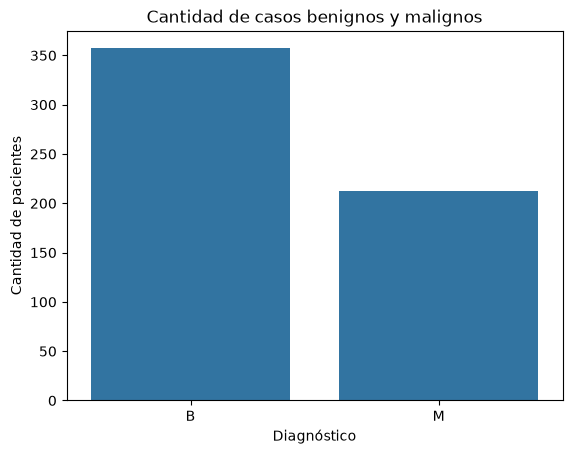

In [327]:
import seaborn as sns

sns.countplot(data=df, x="Diagnosis", order=["B", "M"])

plt.title("Cantidad de casos benignos y malignos")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad de pacientes")
plt.show()

In [330]:
df["Diagnosis"] = df["Diagnosis"].map({"B": 0, "M": 1})
Columnas = df.columns.drop(["ID", "Diagnosis"])

df[Columnas] = (
    (df[Columnas] - df[Columnas].mean())
    / df[Columnas].std()
)

display(df.head())

,ID,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
0,842302,NaN,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,...,1.885031,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312
1,842517,NaN,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,...,1.804340,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943
2,84300903,NaN,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,...,1.510541,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214
3,84348301,NaN,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,...,-0.281217,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672
4,84358402,NaN,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,...,1.297434,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751


In [333]:
Caracteristicas = [
    "RadiusMean", "TextureMean", "PerimeterMean", "AreaMean",
    "SmoothnessMean", "CompactnessMean", "ConcavityMean",
    "ConcavePointsMean", "SymmetryMean", "FractalDimensionMean"
]

df["PromedioMean"] = df[Caracteristicas].mean(axis=1)

display(df[Caracteristicas].head())

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean
0,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,2.253764
1,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,-0.867889
2,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,-0.397658
3,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,4.906602
4,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,-0.561956


In [332]:
df

,ID,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst,PromedioMean
0,842302,NaN,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,...,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312,1.577475
1,842517,NaN,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,...,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943,0.341085
2,84300903,NaN,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,...,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214,1.108923
3,84348301,NaN,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,...,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672,1.594601
4,84358402,NaN,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,...,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751,0.724212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,NaN,2.109139,0.720838,2.058974,2.341795,1.040926,0.218868,1.945573,2.318924,...,0.117596,1.751022,2.013529,0.378033,-0.273077,0.663928,1.627719,-1.358963,-0.708467,1.151251
565,926682,NaN,1.703356,2.083301,1.614511,1.722326,0.102368,-0.017817,0.692434,1.262558,...,2.045599,1.420690,1.493644,-0.690623,-0.394473,0.236365,0.733182,-0.531387,-0.973122,0.788788
566,926954,NaN,0.701667,2.043775,0.672084,0.577445,-0.839745,-0.038646,0.046547,0.105684,...,1.373645,0.578492,0.427529,-0.808876,0.350427,0.326479,0.413705,-1.103578,-0.318129,0.156561
567,927241,NaN,1.836725,2.334403,1.980781,1.733693,1.524426,3.269267,3.294046,2.656528,...,2.235958,2.301575,1.651717,1.429169,3.901415,3.194794,2.287972,1.917396,2.217684,2.180796
